In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import requests
import pandas as pd
import json

response = requests.get('https://api.spacexdata.com/v4/launches')
data = response.json()

print(json.dumps(data[0], indent=2))

{
  "fairings": {
    "reused": false,
    "recovery_attempt": false,
    "recovered": false,
    "ships": []
  },
  "links": {
    "patch": {
      "small": "https://images2.imgbox.com/94/f2/NN6Ph45r_o.png",
      "large": "https://images2.imgbox.com/5b/02/QcxHUb5V_o.png"
    },
    "reddit": {
      "campaign": null,
      "launch": null,
      "media": null,
      "recovery": null
    },
    "flickr": {
      "small": [],
      "original": []
    },
    "presskit": null,
    "webcast": "https://www.youtube.com/watch?v=0a_00nJ_Y88",
    "youtube_id": "0a_00nJ_Y88",
    "article": "https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html",
    "wikipedia": "https://en.wikipedia.org/wiki/DemoSat"
  },
  "static_fire_date_utc": "2006-03-17T00:00:00.000Z",
  "static_fire_date_unix": 1142553600,
  "net": false,
  "window": 0,
  "rocket": "5e9d0d95eda69955f709d1eb",
  "success": false,
  "failures": [
    {
      "time": 33,
      "altitude": null,
      "reason": "merl

In [3]:
print(f'Total launches: {len(data)}')

Total launches: 205


In [4]:
print(data[0].keys())

dict_keys(['fairings', 'links', 'static_fire_date_utc', 'static_fire_date_unix', 'net', 'window', 'rocket', 'success', 'failures', 'details', 'crew', 'ships', 'capsules', 'payloads', 'launchpad', 'flight_number', 'name', 'date_utc', 'date_unix', 'date_local', 'date_precision', 'upcoming', 'cores', 'auto_update', 'tbd', 'launch_library_id', 'id'])


In [5]:
launches = []

for launch in data:
    launches.append({
        'flight_number'   : launch['flight_number'],
        'name'            : launch['name'],
        'date_utc'        : launch['date_utc'],
        'success'         : launch['success'],
        'rocket_id'       : launch['rocket'],
        'launchpad_id'    : launch['launchpad'],
        'payload_id'      : launch['payloads'][0] if launch['payloads'] else None,
        'landing_attempt' : launch['cores'][0]['landing_attempt'] if launch['cores'] else None,
        'landing_success' : launch['cores'][0]['landing_success'] if launch['cores'] else None,
        'landing_type'    : launch['cores'][0]['landing_type'] if launch['cores'] else None,
        'reused'          : launch['cores'][0]['reused'] if launch['cores'] else None,
        'gridfins'        : launch['cores'][0]['gridfins'] if launch['cores'] else None,
        'legs'            : launch['cores'][0]['legs'] if launch['cores'] else None,
    })

df = pd.DataFrame(launches)
print(df.shape)
df.head()

(205, 13)


,flight_number,name,date_utc,success,rocket_id,launchpad_id,payload_id,landing_attempt,landing_success,landing_type,reused,gridfins,legs
0,1,FalconSat,2006-03-24T22:30:00.000Z,False,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86,5eb0e4b5b6c3bb0006eeb1e1,False,None,None,False,False,False
1,2,DemoSat,2007-03-21T01:10:00.000Z,False,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86,5eb0e4b6b6c3bb0006eeb1e2,False,None,None,False,False,False
2,3,Trailblazer,2008-08-03T03:34:00.000Z,False,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86,5eb0e4b6b6c3bb0006eeb1e3,False,None,None,False,False,False
3,4,RatSat,2008-09-28T23:15:00.000Z,True,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86,5eb0e4b7b6c3bb0006eeb1e5,False,None,None,False,False,False
4,5,RazakSat,2009-07-13T03:35:00.000Z,True,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86,5eb0e4b7b6c3bb0006eeb1e6,False,None,None,False,False,False


In [6]:
def get_rocket_name(rocket_id):
    url = f'https://api.spacexdata.com/v4/rockets/{rocket_id}'
    res = requests.get(url).json()
    return res['name']

def get_launchpad_name(launchpad_id):
    url = f'https://api.spacexdata.com/v4/launchpads/{launchpad_id}'
    res = requests.get(url).json()
    return res['name']

def get_payload_info(payload_id):
    if payload_id is None:
        return None, None
    url = f'https://api.spacexdata.com/v4/payloads/{payload_id}'
    res = requests.get(url).json()
    return res.get('mass_kg'), res.get('orbit')

print(df['rocket_id'].nunique())
print(df['launchpad_id'].nunique())

3
4


In [7]:
rocket_map = {}
for rid in df['rocket_id'].unique():
    url = f'https://api.spacexdata.com/v4/rockets/{rid}'
    rocket_map[rid] = requests.get(url).json()['name']

launchpad_map = {}
for lid in df['launchpad_id'].unique():
    url = f'https://api.spacexdata.com/v4/launchpads/{lid}'
    launchpad_map[lid] = requests.get(url).json()['name']

df['rocket']    = df['rocket_id'].map(rocket_map)
df['launchpad'] = df['launchpad_id'].map(launchpad_map)

print(df['rocket'].value_counts())
print(df['launchpad'].value_counts())

rocket
Falcon 9        195
Falcon 1          5
Falcon Heavy      5
Name: count, dtype: int64
launchpad
CCSFS SLC 40       112
KSC LC 39A          58
VAFB SLC 4E         30
Kwajalein Atoll      5
Name: count, dtype: int64


In [8]:
payload_map = {}
for pid in df['payload_id'].dropna().unique():
    url = f'https://api.spacexdata.com/v4/payloads/{pid}'
    res = requests.get(url).json()
    payload_map[pid] = {
        'mass_kg' : res.get('mass_kg'),
        'orbit'   : res.get('orbit')
    }

df['mass_kg'] = df['payload_id'].map(lambda x: payload_map.get(x, {}).get('mass_kg'))
df['orbit']   = df['payload_id'].map(lambda x: payload_map.get(x, {}).get('orbit'))

print(df['orbit'].value_counts())
print(df[['mass_kg']].describe())

orbit
VLEO     59
GTO      36
ISS      33
LEO      20
PO       15
SSO      13
MEO       8
TLI       2
GEO       2
ES-L1     1
HCO       1
HEO       1
SO        1
Name: count, dtype: int64
            mass_kg
count    166.000000
mean    7842.388855
std     5568.661770
min       20.000000
25%     2770.000000
50%     5900.000000
75%    13260.000000
max    15600.000000


In [9]:
df = df[df['rocket'] == 'Falcon 9'].reset_index(drop=True)


df = df.drop(['rocket_id', 'launchpad_id', 
              'payload_id', 'rocket'], axis=1)


df['date_utc'] = pd.to_datetime(df['date_utc'])
df['year']     = df['date_utc'].dt.year
df['month']    = df['date_utc'].dt.month

print(df.shape)
print(df.isnull().sum())

(195, 15)
flight_number       0
name                0
date_utc            0
success            17
landing_attempt    16
landing_success    42
landing_type       40
reused              6
gridfins            6
legs                6
launchpad           0
mass_kg            36
orbit              12
year                0
month               0
dtype: int64


In [10]:
df = df[df['landing_attempt'] == True].reset_index(drop=True)


print(df.shape)
print(df['landing_success'].value_counts())
print(df.isnull().sum())

(155, 15)
landing_success
True     142
False     11
Name: count, dtype: int64
flight_number       0
name                0
date_utc            0
success             1
landing_attempt     0
landing_success     2
landing_type        0
reused              0
gridfins            0
legs                0
launchpad           0
mass_kg            20
orbit               1
year                0
month               0
dtype: int64


In [11]:
df = df.dropna(subset=['landing_success'])


df['mass_kg'] = df['mass_kg'].fillna(df['mass_kg'].median())


df['orbit']   = df['orbit'].fillna(df['orbit'].mode()[0])
df['success'] = df['success'].fillna(df['success'].mode()[0])


df['landing_success'] = df['landing_success'].astype(int)

print(df.shape)
print(df.isnull().sum().sum()) 

(153, 15)
0


/tmp/ipykernel_16/1280247370.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['success'] = df['success'].fillna(df['success'].mode()[0])


In [12]:
df['payload_category'] = pd.cut(df['mass_kg'], 
                                bins=[0, 3000, 7000, 12000, 16000],
                                labels=['Light', 'Medium', 'Heavy', 'Super Heavy'])


df['reused'] = df['reused'].astype(int)
df['gridfins'] = df['gridfins'].astype(int)
df['legs'] = df['legs'].astype(int)


site_success = df.groupby('launchpad')['landing_success'].transform('mean')
df['site_success_rate'] = site_success


orbit_success = df.groupby('orbit')['landing_success'].transform('mean')
df['orbit_success_rate'] = orbit_success


df['is_recent'] = (df['year'] >= 2018).astype(int)

print(df.shape)
print(df.columns.tolist())

(153, 19)
['flight_number', 'name', 'date_utc', 'success', 'landing_attempt', 'landing_success', 'landing_type', 'reused', 'gridfins', 'legs', 'launchpad', 'mass_kg', 'orbit', 'year', 'month', 'payload_category', 'site_success_rate', 'orbit_success_rate', 'is_recent']


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['launchpad']        = le.fit_transform(df['launchpad'])
df['orbit']            = le.fit_transform(df['orbit'])
df['landing_type']     = le.fit_transform(df['landing_type'])
df['payload_category'] = le.fit_transform(df['payload_category'])


X = df.drop(['landing_success', 'name', 
             'date_utc', 'landing_attempt'], axis=1)
y = df['landing_success']

print(X.shape)
print(X.columns.tolist())

(153, 15)
['flight_number', 'success', 'landing_type', 'reused', 'gridfins', 'legs', 'launchpad', 'mass_kg', 'orbit', 'year', 'month', 'payload_category', 'site_success_rate', 'orbit_success_rate', 'is_recent']


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


rf = RandomForestClassifier(n_estimators=500, max_depth=5, 
                             max_samples=0.8, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
rf_acc = accuracy_score(y_val, rf_pred)


xgb = XGBClassifier(n_estimators=500, max_depth=5, 
                     subsample=0.8, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_val)
xgb_acc = accuracy_score(y_val, xgb_pred)

print(f'Random Forest : {rf_acc:.4f}')
print(f'XGBoost       : {xgb_acc:.4f}')

Random Forest : 0.9032
XGBoost       : 0.9032


In [15]:
print(classification_report(y_val, xgb_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.90      1.00      0.95        28

    accuracy                           0.90        31
   macro avg       0.45      0.50      0.47        31
weighted avg       0.82      0.90      0.86        31



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


weights = compute_class_weight('balanced',
                                classes=np.array([0,1]),
                                y=y_train)
w_dict = {0: weights[0], 1: weights[1]}


rf = RandomForestClassifier(n_estimators=500, max_depth=5,
                             max_samples=0.8, random_state=42,
                             class_weight='balanced')
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)


ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=500, max_depth=5,
                     subsample=0.8, random_state=42,
                     scale_pos_weight=ratio)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_val)

print("Random Forest:")
print(classification_report(y_val, rf_pred))

print("XGBoost:")
print(classification_report(y_val, xgb_pred))

Random Forest:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.90      0.96      0.93        28

    accuracy                           0.87        31
   macro avg       0.45      0.48      0.47        31
weighted avg       0.81      0.87      0.84        31

XGBoost:
              precision    recall  f1-score   support

           0       0.25      0.33      0.29         3
           1       0.93      0.89      0.91        28

    accuracy                           0.84        31
   macro avg       0.59      0.61      0.60        31
weighted avg       0.86      0.84      0.85        31



In [17]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}')

Before SMOTE: {1: 114, 0: 8}
After SMOTE: {1: 114, 0: 114}


In [18]:
rf = RandomForestClassifier(n_estimators=500, max_depth=5,
                             max_samples=0.8, random_state=42)
rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_val)


xgb = XGBClassifier(n_estimators=500, max_depth=5,
                     subsample=0.8, random_state=42)
xgb.fit(X_train_sm, y_train_sm)



xgb_pred = xgb.predict(X_val)

print("Random Forest:")
print(classification_report(y_val, rf_pred))

print("XGBoost:")
print(classification_report(y_val, xgb_pred))


import joblib
joblib.dump(xgb, 'spacex_xgb_model.pkl')
print("Model saved!")

Random Forest:
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.93      0.96      0.95        28

    accuracy                           0.90        31
   macro avg       0.72      0.65      0.67        31
weighted avg       0.89      0.90      0.89        31

XGBoost:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.96      0.96      0.96        28

    accuracy                           0.94        31
   macro avg       0.82      0.82      0.82        31
weighted avg       0.94      0.94      0.94        31

Model saved!


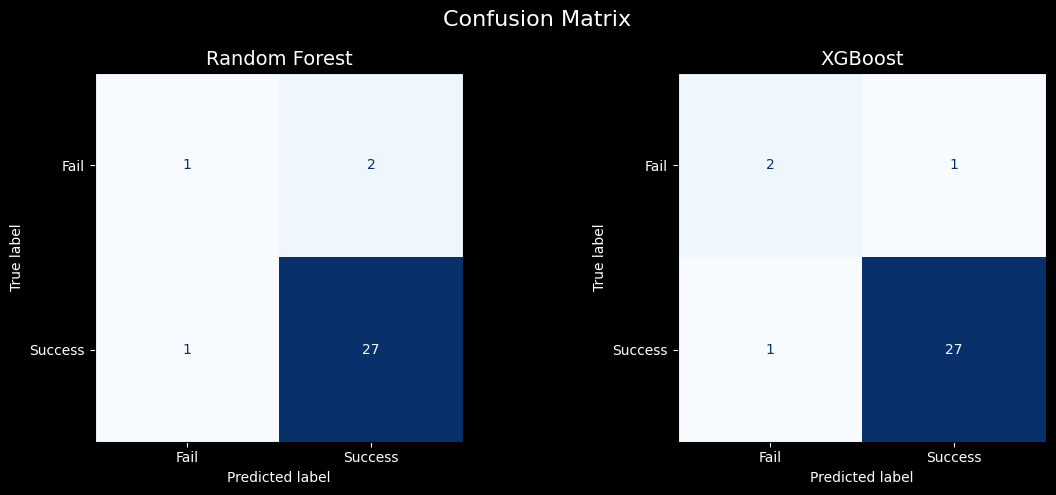

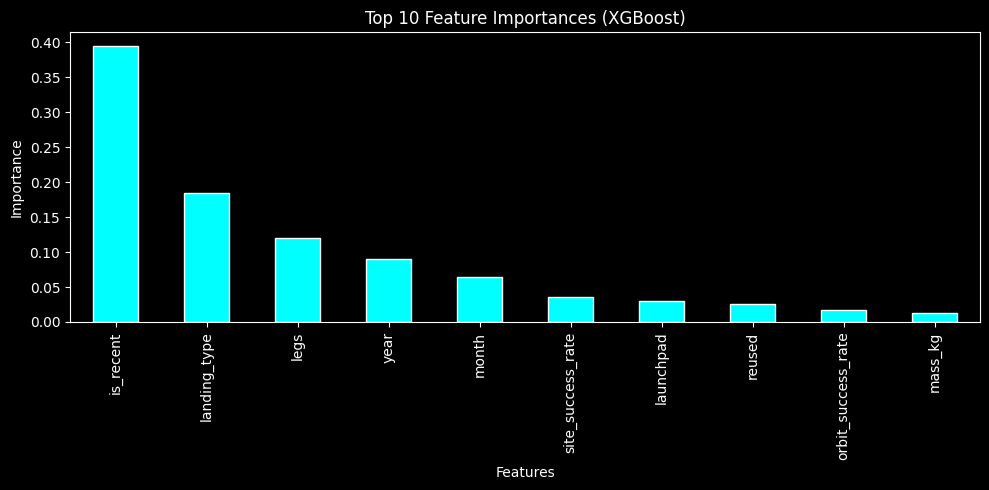

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd


fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='black')

for ax, pred, title in zip(axes,
                            [rf_pred, xgb_pred],
                            ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_val, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Success'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_facecolor('black')
    ax.set_title(title, color='white', fontsize=14)
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.tick_params(colors='white')

plt.suptitle('Confusion Matrix', color='white', fontsize=16)
plt.tight_layout()
plt.show()


feat_imp = pd.Series(xgb.feature_importances_,
                     index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5), facecolor='black')
ax.set_facecolor('black')
feat_imp.head(10).plot(kind='bar', ax=ax, color='cyan', edgecolor='white')
ax.set_title('Top 10 Feature Importances (XGBoost)', color='white')
ax.set_xlabel('Features', color='white')
ax.set_ylabel('Importance', color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('white')
plt.tight_layout()
plt.show()